In [ ]:
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 16.1 MB/s eta 0:00:00


In [ ]:
# download_abide_preproc.py
#
# Author: Daniel Clark, 2015
# Updated to python 3 and to support downloading by DX, Cameron Craddock, 2019

"""
This script downloads data from the Preprocessed Connetomes Project's
ABIDE Preprocessed data release and stores the files in a local
directory; users specify derivative, pipeline, strategy, and optionally
age ranges, sex, site of interest

Usage:
    python download_abide_preproc.py -d <derivative> -p <pipeline>
                                     -s <strategy> -o <out_dir>
                                     [-lt <less_than>] [-gt <greater_than>]
                                     [-x <sex>] [-t <site>]
"""


# Main collect and download function
def collect_and_download(derivative, pipeline, strategy, out_dir, less_than, greater_than, site, sex, diagnosis):
    """

    Function to collect and download images from the ABIDE preprocessed
    directory on FCP-INDI's S3 bucket

    Parameters
    ----------
    derivative : string
        derivative or measure of interest
    pipeline : string
        pipeline used to process data of interest
    strategy : string
        noise removal strategy used to process data of interest
    out_dir : string
        filepath to a local directory to save files to
    less_than : float
        upper age (years) threshold for participants of interest
    greater_than : float
        lower age (years) threshold for participants of interest
    site : string
        acquisition site of interest
    sex : string
        'M' or 'F' to indicate whether to download male or female data
    diagnosis : string
        'asd', 'tdc', or 'both' corresponding to the diagnosis of the
        participants for whom data should be downloaded

    Returns
    -------
    None
        this function does not return a value; it downloads data from
        S3 to a local directory

    :param derivative:
    :param pipeline:
    :param strategy:
    :param out_dir:
    :param less_than:
    :param greater_than:
    :param site:
    :param sex:
    :param diagnosis:
    :return:
    """

    # Import packages
    import os
    import urllib.request as request

    # Init variables
    mean_fd_thresh = 0.2
    s3_prefix = 'https://s3.amazonaws.com/fcp-indi/data/Projects/'\
                'ABIDE_Initiative'
    s3_pheno_path = '/'.join([s3_prefix, 'Phenotypic_V1_0b_preprocessed1.csv'])

    # Format input arguments to be lower case, if not already
    derivative = derivative.lower()
    pipeline = pipeline.lower()
    strategy = strategy.lower()

    # Check derivative for extension
    if 'roi' in derivative:
        extension = '.1D'
    else:
        extension = '.nii.gz'

    # If output path doesn't exist, create it
    if not os.path.exists(out_dir):
        print('Could not find {0}, creating now...'.format(out_dir))
        os.makedirs(out_dir)

    # Load the phenotype file from S3
    s3_pheno_file = request.urlopen(s3_pheno_path)
    pheno_list = s3_pheno_file.readlines()
    print(pheno_list[0])

    # Get header indices
    header = pheno_list[0].decode().split(',')
    try:
        site_idx = header.index('SITE_ID')
        file_idx = header.index('FILE_ID')
        age_idx = header.index('AGE_AT_SCAN')
        sex_idx = header.index('SEX')
        dx_idx = header.index('DX_GROUP')
        mean_fd_idx = header.index('func_mean_fd')
    except Exception as exc:
        err_msg = 'Unable to extract header information from the pheno file: {0}\nHeader should have pheno info:' \
                  ' {1}\nError: {2}'.format(s3_pheno_path, str(header), exc)
        raise Exception(err_msg)

    # Go through pheno file and build download paths
    print('Collecting images of interest...')
    s3_paths = []
    for pheno_row in pheno_list[1:]:

        # Comma separate the row
        cs_row = pheno_row.decode().split(',')

        try:
            # See if it was preprocessed
            row_file_id = cs_row[file_idx]
            # Read in participant info
            row_site = cs_row[site_idx]
            row_age = float(cs_row[age_idx])
            row_sex = cs_row[sex_idx]
            row_dx = cs_row[dx_idx]
            row_mean_fd = float(cs_row[mean_fd_idx])
        except Exception as e:
            err_msg = 'Error extracting info from phenotypic file, skipping...'
            print(err_msg)
            continue

        # If the filename isn't specified, skip
        if row_file_id == 'no_filename':
            continue
        # If mean fd is too large, skip
        if row_mean_fd >= mean_fd_thresh:
            continue

        # Test phenotypic criteria (three if's looks cleaner than one long if)
        # Test sex
        if (sex == 'M' and row_sex != '1') or (sex == 'F' and row_sex != '2'):
            continue

        if (diagnosis == 'asd' and row_dx != '1') or (diagnosis == 'tdc' and row_dx != '2'):
            continue

        # Test site
        if site is not None and site.lower() != row_site.lower():
            continue
        # Test age range
        if greater_than < row_age < less_than:
            filename = row_file_id + '_' + derivative + extension
            s3_path = '/'.join([s3_prefix, 'Outputs', pipeline, strategy, derivative, filename])
            print('Adding {0} to download queue...'.format(s3_path))
            s3_paths.append(s3_path)
        else:
            continue

    # And download the items
    total_num_files = len(s3_paths)
    for path_idx, s3_path in enumerate(s3_paths):
        rel_path = s3_path.lstrip(s3_prefix)
        download_file = os.path.join(out_dir, rel_path)
        download_dir = os.path.dirname(download_file)
        if not os.path.exists(download_dir):
            os.makedirs(download_dir)
        try:
            if not os.path.exists(download_file):
                print('Retrieving: {0}'.format(download_file))
                request.urlretrieve(s3_path, download_file)
                print('{0:3f}% percent complete'.format(100*(float(path_idx+1)/total_num_files)))
            else:
                print('File {0} already exists, skipping...'.format(download_file))
        except Exception as exc:
            print('There was a problem downloading {0}.\n Check input arguments and try again.'.format(s3_path))

    # Print all done
    print('Done!')


desired_derivative = "func_preproc"
desired_pipeline = "cpac"
desired_strategy = "filt_noglobal"
download_data_dir = "/content/data"
desired_age_max = 30
desired_age_min = 15
desired_site = "Olin"
desired_diagnosis = "both"

collect_and_download("fun_preproc", "cpac", "filt_global", "/content/data", 30, 15, None, None, "both")
#collect_and_download(desired_derivative, desired_pipeline, desired_strategy, download_data_dir, desired_age_max,
                         #desired_age_min, None, desired_diagnosis)

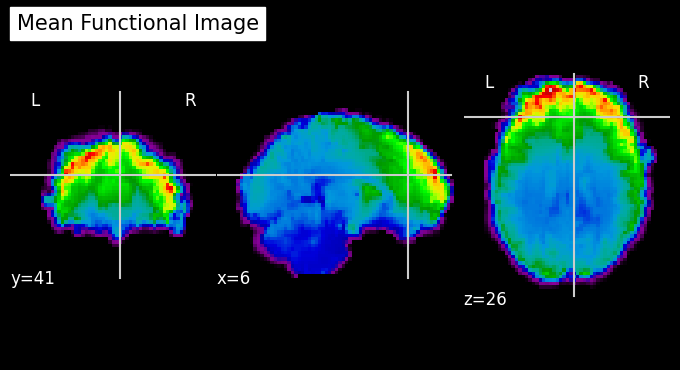

In [ ]:
from nilearn import plotting
# Load the mean functional image
mean_func_path = "/content/data/Outputs/ccs/filt_noglobal/func_mean/Yale_0050607_func_mean.nii.gz"
plotting.plot_epi(mean_func_path, title='Mean Functional Image')
plotting.show()


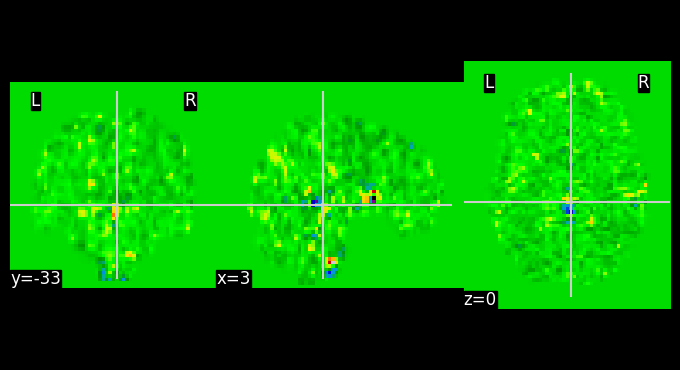

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

# Load the fMRI image
fmri_image_path = "/content/data/Outputs/cpac/filt_noglobal/func_preproc/Olin_0050104_func_preproc.nii.gz"
fmri_image = nib.load(fmri_image_path)

#over time - 4th dimension
volume_to_plot =  # Index of the volume you want to visualize
plotting.plot_epi(fmri_image.slicer[..., volume_to_plot])
plt.show()

In [4]:
!python3 /content/download_data.py -d alff -p ccs -s filt_noglobal -o /content/DATA

python3: can't open file '/content/download_data.py': [Errno 2] No such file or directory


In [5]:
!python download_abide_preproc.py -d rois_aal -p cpac -s nofilt_noglobal -o /content/data


No upper age threshold specified
No lower age threshold specified
No site specified, using all sites...
No sex specified, using all sexes...
Could not find /content/data, creating now...
b',Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,HANDEDNESS_SCORES,FIQ,VIQ,PIQ,FIQ_TEST_TYPE,VIQ_TEST_TYPE,PIQ_TEST_TYPE,ADI_R_SOCIAL_TOTAL_A,ADI_R_VERBAL_TOTAL_BV,ADI_RRB_TOTAL_C,ADI_R_ONSET_TOTAL_D,ADI_R_RSRCH_RELIABLE,ADOS_MODULE,ADOS_TOTAL,ADOS_COMM,ADOS_SOCIAL,ADOS_STEREO_BEHAV,ADOS_RSRCH_RELIABLE,ADOS_GOTHAM_SOCAFFECT,ADOS_GOTHAM_RRB,ADOS_GOTHAM_TOTAL,ADOS_GOTHAM_SEVERITY,SRS_VERSION,SRS_RAW_TOTAL,SRS_AWARENESS,SRS_COGNITION,SRS_COMMUNICATION,SRS_MOTIVATION,SRS_MANNERISMS,SCQ_TOTAL,AQ_TOTAL,COMORBIDITY,CURRENT_MED_STATUS,MEDICATION_NAME,OFF_STIMULANTS_AT_SCAN,VINELAND_RECEPTIVE_V_SCALED,VINELAND_EXPRESSIVE_V_SCALED,VINELAND_WRITTEN_V_SCALED,VINELAND_COMMUNICATION_STANDARD,VINELAND_PERSONAL_V_SCALED,VINELAND_DOMESTIC_V_SCALED,VINELAND_COMMUNITY_

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 21.6 MB/s eta 0:00:00


(196, 116)


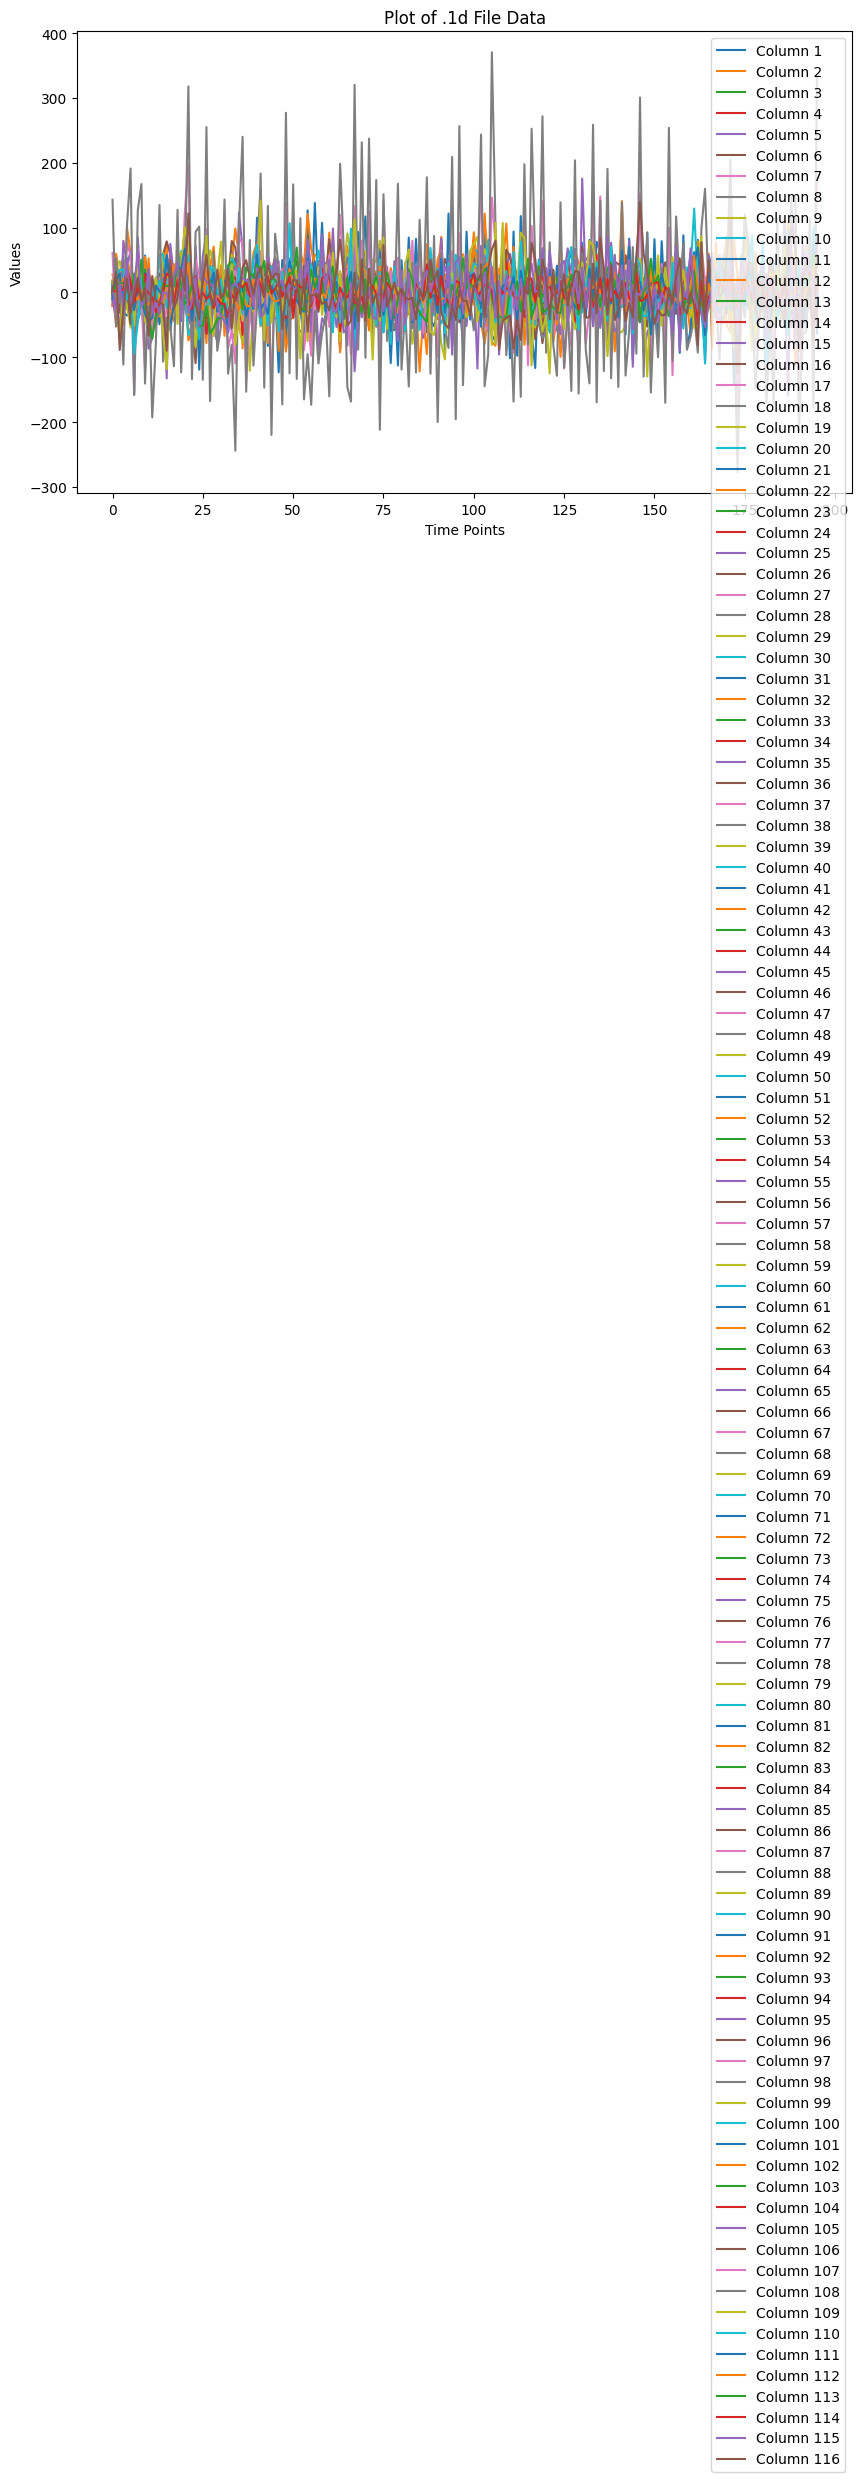

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Replace 'path/to/yourfile.1d' with the actual file path
file_path = '/content/data/Outputs/cpac/nofilt_noglobal/rois_aal/Pitt_0050004_rois_aal.1D'

# Load the .1d file
data = np.loadtxt(file_path)

# Print the data
print(data.shape)

# Plot the data
plt.figure(figsize=(10, 6))

for i in range(data.shape[1]):
    plt.plot(data[:, i], label=f'Column {i+1}')

plt.xlabel('Time Points')
plt.ylabel('Values')
plt.title('Plot of .1d File Data')
plt.legend()
plt.show()



In [11]:
!python download_abide_preproc.py -d func_mean -p cpac -s nofilt_noglobal -o /content/data

No upper age threshold specified
No lower age threshold specified
No site specified, using all sites...
No sex specified, using all sexes...
b',Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,HANDEDNESS_SCORES,FIQ,VIQ,PIQ,FIQ_TEST_TYPE,VIQ_TEST_TYPE,PIQ_TEST_TYPE,ADI_R_SOCIAL_TOTAL_A,ADI_R_VERBAL_TOTAL_BV,ADI_RRB_TOTAL_C,ADI_R_ONSET_TOTAL_D,ADI_R_RSRCH_RELIABLE,ADOS_MODULE,ADOS_TOTAL,ADOS_COMM,ADOS_SOCIAL,ADOS_STEREO_BEHAV,ADOS_RSRCH_RELIABLE,ADOS_GOTHAM_SOCAFFECT,ADOS_GOTHAM_RRB,ADOS_GOTHAM_TOTAL,ADOS_GOTHAM_SEVERITY,SRS_VERSION,SRS_RAW_TOTAL,SRS_AWARENESS,SRS_COGNITION,SRS_COMMUNICATION,SRS_MOTIVATION,SRS_MANNERISMS,SCQ_TOTAL,AQ_TOTAL,COMORBIDITY,CURRENT_MED_STATUS,MEDICATION_NAME,OFF_STIMULANTS_AT_SCAN,VINELAND_RECEPTIVE_V_SCALED,VINELAND_EXPRESSIVE_V_SCALED,VINELAND_WRITTEN_V_SCALED,VINELAND_COMMUNICATION_STANDARD,VINELAND_PERSONAL_V_SCALED,VINELAND_DOMESTIC_V_SCALED,VINELAND_COMMUNITY_V_SCALED,VINELAND_DAILYLVNG_STANDARD,VINELAND_

(61, 73, 61)


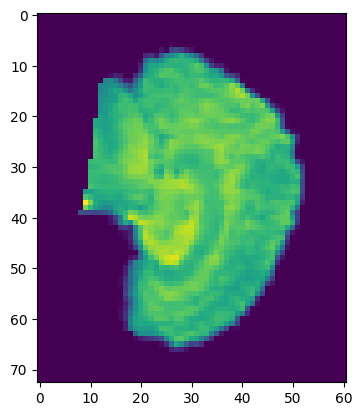

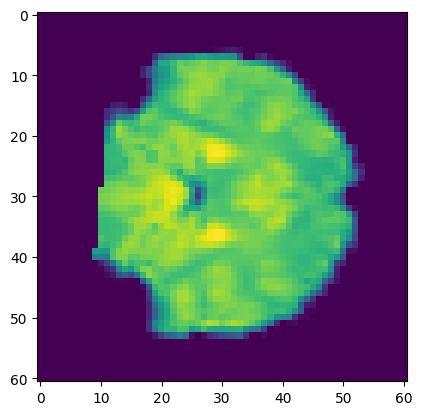

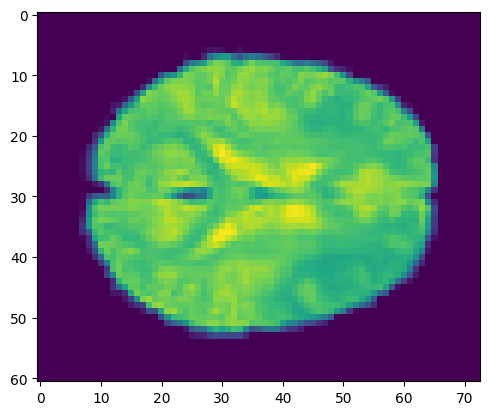

In [16]:
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
fmri_image = nib.load("/content/data/Outputs/cpac/nofilt_noglobal/func_mean/Pitt_0050004_func_mean.nii.gz")
image_data = fmri_image.get_fdata()
print(image_data.shape)

axial_slice = image_data[33,:,:]
plt.imshow(axial_slice)
plt.show()


axial_slice = image_data[:,30,:]
plt.imshow(axial_slice)
plt.show()


axial_slice = image_data[:,:,30]
plt.imshow(axial_slice)
plt.show()

In [ ]:
!python download_abide_preproc.py -d func_preproc -p cpac -s nofilt_noglobal -o /content/data

(61, 73, 61, 196)


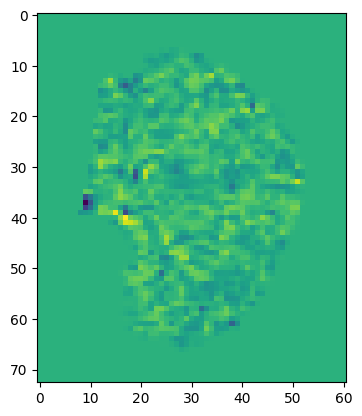

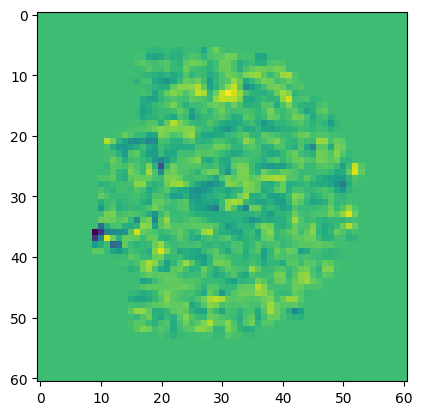

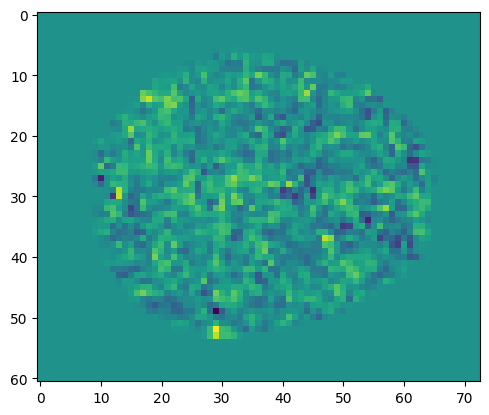

In [17]:
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
fmri_image = nib.load("/content/data/Outputs/cpac/nofilt_noglobal/func_preproc/Pitt_0050004_func_preproc.nii.gz")
image_data = fmri_image.get_fdata()
print(image_data.shape)


axial_slice = image_data[33,:,:,80]
plt.imshow(axial_slice)
plt.show()

axial_slice = image_data[:,33,:,80]
plt.imshow(axial_slice)
plt.show()

axial_slice = image_data[:,:,33,80]
plt.imshow(axial_slice)
plt.show()

In [21]:
#python download_abide_preproc.py -d /path/to/download/folder -p CPAC -s anat


!python download_abide_preproc.py -d anat -p CPAC -s no_output -o /path/to/output/directory



No upper age threshold specified
No lower age threshold specified
No site specified, using all sites...
No sex specified, using all sexes...
Could not find /path/to/output/directory, creating now...
b',Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,HANDEDNESS_SCORES,FIQ,VIQ,PIQ,FIQ_TEST_TYPE,VIQ_TEST_TYPE,PIQ_TEST_TYPE,ADI_R_SOCIAL_TOTAL_A,ADI_R_VERBAL_TOTAL_BV,ADI_RRB_TOTAL_C,ADI_R_ONSET_TOTAL_D,ADI_R_RSRCH_RELIABLE,ADOS_MODULE,ADOS_TOTAL,ADOS_COMM,ADOS_SOCIAL,ADOS_STEREO_BEHAV,ADOS_RSRCH_RELIABLE,ADOS_GOTHAM_SOCAFFECT,ADOS_GOTHAM_RRB,ADOS_GOTHAM_TOTAL,ADOS_GOTHAM_SEVERITY,SRS_VERSION,SRS_RAW_TOTAL,SRS_AWARENESS,SRS_COGNITION,SRS_COMMUNICATION,SRS_MOTIVATION,SRS_MANNERISMS,SCQ_TOTAL,AQ_TOTAL,COMORBIDITY,CURRENT_MED_STATUS,MEDICATION_NAME,OFF_STIMULANTS_AT_SCAN,VINELAND_RECEPTIVE_V_SCALED,VINELAND_EXPRESSIVE_V_SCALED,VINELAND_WRITTEN_V_SCALED,VINELAND_COMMUNICATION_STANDARD,VINELAND_PERSONAL_V_SCALED,VINELAND_DOMESTIC_V_SCALED,VINELAN

In [24]:
import os
import requests
import pandas as pd
import nibabel as nib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define the base URL for the ABIDE I preprocessed data
BASE_URL = 'https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs'

# Specify the preprocessing pipeline and the type of data
pipeline = 'CPAC'  # Replace with your pipeline of choice: 'ANTs', 'CPAC', 'CCS', 'DPARSF'
data_type = 'anat'  # Specify anatomical data (T1-weighted images)

# Output directory
output_dir = '/content/data'
os.makedirs(output_dir, exist_ok=True)

# Load the phenotype file to get subject IDs
phenotype_file = '/content/Phenotypic_V1_0b_preprocessed1.csv'
df = pd.read_csv(phenotype_file)

# Extract subject IDs and labels
subject_ids = df['SUB_ID'].values
labels = df['DX_GROUP'].values  # 1 = ASD, 2 = Control
labels = labels - 1  # Convert labels to binary (0 = Control, 1 = ASD)

# Function to download a file from a URL
def download_file(url, local_filename):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Check for HTTP errors
        with open(local_filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f'Successfully downloaded {local_filename}')
    except requests.HTTPError as e:
        print(f'HTTPError: {e} - {url}')
    except requests.RequestException as e:
        print(f'RequestException: {e} - {url}')
    except Exception as e:
        print(f'Error: {e} - {url}')

# Function to load a NIfTI file and return the flattened image
def load_nifti_image(file_path):
    try:
        img = nib.load(file_path)
        data = img.get_fdata()
        return data.flatten()
    except Exception as e:
        print(f'Error loading NIfTI file {file_path}: {e}')
        return None

# Loop over each subject and download the T1-weighted images
X = []
y = []

for subject_id, label in zip(subject_ids, labels):
    file_path = f'{BASE_URL}/{pipeline}/{data_type}/sub-{subject_id}/anat/sub-{subject_id}_T1w.nii.gz'
    local_file = os.path.join(output_dir, f'sub-{subject_id}_T1w.nii.gz')

    download_file(file_path, local_file)

    # Load the MRI data if the download was successful
    if os.path.exists(local_file):
        image_data = load_nifti_image(local_file)
        if image_data is not None:
            X.append(image_data)
            y.append(label)

X = np.array(X)
y = np.array(y)

# Check if any data was loaded
if X.shape[0] == 0:
    print("No data was loaded. Check your downloads.")
    exit()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


HTTPError: 404 Client Error: Not Found for url: https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50002/anat/sub-50002_T1w.nii.gz - https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50002/anat/sub-50002_T1w.nii.gz
HTTPError: 404 Client Error: Not Found for url: https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50003/anat/sub-50003_T1w.nii.gz - https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50003/anat/sub-50003_T1w.nii.gz
HTTPError: 404 Client Error: Not Found for url: https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50004/anat/sub-50004_T1w.nii.gz - https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-50004/anat/sub-50004_T1w.nii.gz
HTTPError: 404 Client Error: Not Found for url: https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/CPAC/anat/sub-5

KeyboardInterrupt: 

In [36]:
!pip install nilearn.datasets.utils

ERROR: Could not find a version that satisfies the requirement nilearn.datasets.utils (from versions: none)
ERROR: No matching distribution found for nilearn.datasets.utils


In [42]:
!python download_ABIDE.py

Loading phenotypic information
Successfully downloaded ./temp/phenotypic/ho_labels.csv
   index              area
0     10     Left Thalamus
1     11      Left Caudate
2     12      Left Putamen
3     13     Left Pallidum
4     17  Left Hippocampus
Constructing the graph representation of the brain...
(111, 2)
Processing the adjacent matrix...
Done!
processing the graph indicator...
Done!
processing the graph labels...
Done!
processing the node attributes...
The shape of node attributes is (96681, 78)
Done!
processing the node labels...
Done!
Deleting the raw ABIDE I data...


In [ ]:
from nilearn import datasets
from nilearn.datasets import utils

In [ ]:
!python3 download_ABIDE.py -d func_preproc -p cpac -s filt_global -o /absolute/path/to/directory

usage: download_ABIDE.py [-h] [--root ROOT] [--verbose VERBOSE]
download_ABIDE.py: error: unrecognized arguments: -d func_preproc -p cpac -s filt_noglobal -o /absolute/path/to/directory


In [3]:
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting
fmri_image = nib.load("/content/data/Outputs/cpac/filt_global/alff/CMU_b_0050657_alff.nii.gz")
image_data = fmri_image.get_fdata()
print(image_data.shape)

FileNotFoundError: No such file or no access: '/content/data/Outputs/cpac/filt_global/alff/CMU_b_0050657_alff.nii.gz'

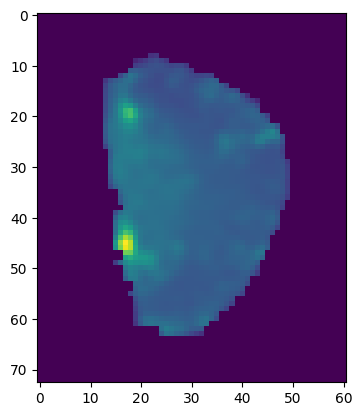

In [ ]:
import os
import nibabel as nib
import numpy as np
def convert_1d_to_nifti(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for file in os.listdir(input_dir):
        if file.endswith('.1D'):
            print(f"Processing file: {file}")
            input_file = os.path.join(input_dir, file)
            output_file = os.path.join(output_dir, file.replace('.1D', '.nii.gz'))

            data = np.loadtxt(input_file)
            data = data.reshape(data.shape[0], 1, 1, -1)
            nifti_img = nib.Nifti1Image(data, np.eye(4))
            nib.save(nifti_img, output_file)
            print(f"Saved file: {output_file}")

            # Remove the '.1D' file after successful conversion
            os.remove(input_file)
            print(f"Removed file: {input_file}")


convert_1d_to_nifti("/content/DATA/Outputs/ccs/filt_noglobal/rois_ho", "/content/example")


In [ ]:
!pip install nibabel matplotlib

In [ ]:
print(data.shape)

(235, 1, 1, 111)


(235, 1, 1)


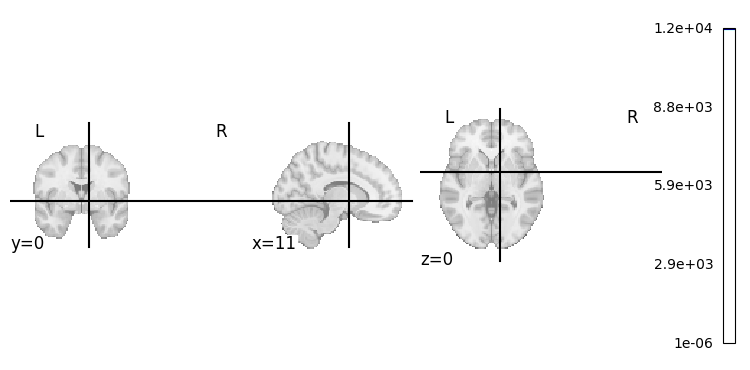

In [ ]:
#PLAYING WITH ROIS.ho from nilearn import plotting
from nilearn import image
#image.load_img("/content/example/CMU_a_0050649_rois_ho.nii.gz")
first_img = image.index_img("/content/example/CMU_a_0050649_rois_ho.nii.gz", 100)
print(first_img.shape)
plotting.plot_stat_map(first_img)


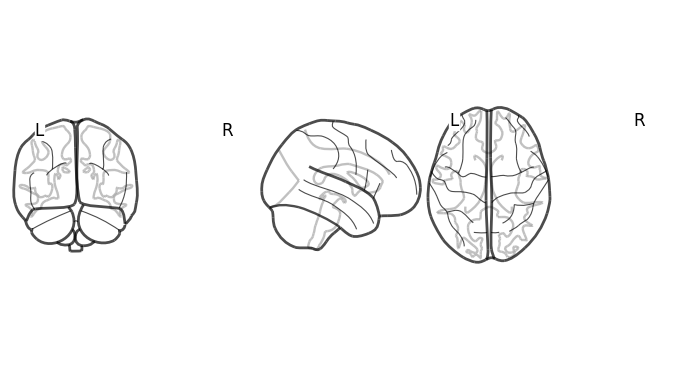

In [ ]:
plotting.plot_glass_brain(first_img)

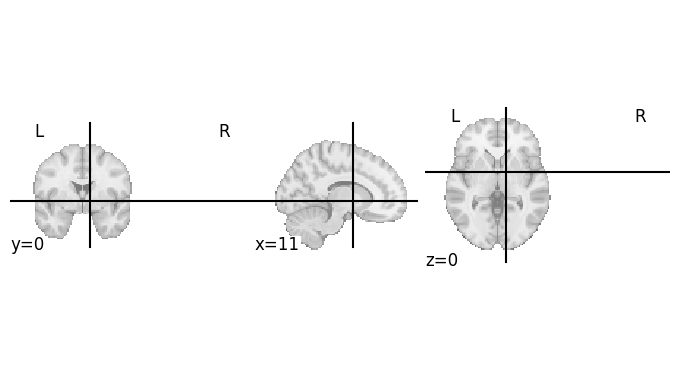

In [ ]:
plotting.plot_roi(first_img)

/usr/local/lib/python3.10/dist-packages/nilearn/plotting/displays/_axes.py:74: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = getattr(ax, type)(
/usr/local/lib/python3.10/dist-packages/nilearn/plotting/displays/_axes.py:52: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.ax.axis(self.get_object_bounds())
/usr/local/lib/python3.10/dist-packages/nilearn/plotting/displays/_axes.py:74: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = getattr(ax, type)(
/usr/local/lib/python3.10/dist-packages/nilearn/plotting/displays/_axes.py:52: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.ax.axis(self.get_object_bounds())


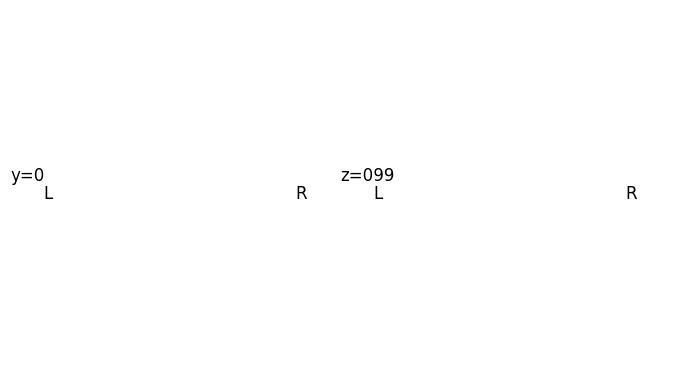

In [ ]:
plotting.plot_img(first_img)

In [ ]:
#What we need:
'''
  in CLI: $ python3 download_abide_preproc.py -d rois_ho -p ccs -s filt_noglobal -o /absolute/path/to/directory
  in CLI: $ python3 download_abide_preproc.py -d func_preproc -p cpac -s filt_noglobal -o /absolute/path/to/directory
  in CLI: $ python3 download_abide_preproc.py -d func_mean -p cpac -s filt_noglobal -o /absolute/path/to/directory


  _______________________________________________________________________________________________________________________________________________________

  What we need: Structural/anatomical data, structural image processing, anatomical ROI for all patients 1-autistic & 2-control.

  How we get it: Through selecting the parameters below and using FSL toolkit [https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/]
  _______________________________________________________________________________________________________________________________________________________

                                     -------------IMPORTANT PARAMETER INFORMATION:-------------

<DERIVATIVE #1> rois_ho: Harvard-Oxford (HO): The HO atlas distributed with FSL is split into cortical and subcortical
 probabilistic atlases. A 25% threshold was applied to each of these atlases and they were subsequently bisected into
 left and right hemispheres at the midline (x=0). ROIs representing left/right WM, left/right GM, left/right CSF and
 brainstem were removed from the subcortical atlas. The subcortical and cortical ROIs were combined and then fractionated
 into functional resolution using nearest-neighbor interpolation.
                          ------------------------------------------------------------------------------------------
<DERIVATIVE #2> func_preproc:  preprocessed functional image, which has undergone steps such as motion correction, slice
timing correction, and normalization, among others. This derivative is generally used for functional connectivity analyses,
such as seed-based or network-based analyses.
                           -------------------------------------------------------------------------------------------
<DERIVATIVE #3> func_mean: derivative is the mean preprocessed functional image, which is the average of all volumes in the
 functional timeseries. This derivative is generally used for visual inspection of the data or as a reference image for
 registration to other brain images.
________________________________________________________________________________________________________________________________________________________________

<PIPELINE #1> Connectome Computation System (CCS): Structural image preprocessing MRI denoised by a spatially adaptive non-local
means filter (Xing et al., 2011; Zuo and Xing, 2011) using the extensions utility of VBM toolboxes of SPM8.
  Skull stripped with FREESURFER step (-autorecon1), integrating with BET tool in FSL. Specifically, two fractional intensity
  thresholds, loose and tight, were used to extract brain in FSL. Subsequently, three brain masks, one from FREESURFER, two from
  BET were manually screened for users to choose the best one for the next surface reconstruction step. Occasionally, the bad skull
  strip were manual fixed in this step. Surface reconstructed in FREESURFER (-autorecon2 and –autorecon3). Normalized individual
  skull stripped brain according to MNI152 standard template (MNI152_T1_2mm_brain) with linear affine and followed by the nonlinear
  warp with FLIRT and FNIRT in FSL.
                               -------------------------------------------------------------------------------------------
<PIPELINE #2> CPAC: The Configurable Pipeline for the Analysis of Connectomes (CPAC) is a configurable software pipeline for the preprocessing
and analysis of resting-state functional MRI (rfMRI) data. It is designed to be flexible and can be configured for a variety of analysis
workflows, such as preprocessing with different software packages and pipelines, nuisance regression, functional connectivity analysis, and more.
CPAC has been widely used in the field of connectomics and has been shown to produce high-quality preprocessing results. One of the
strengths of CPAC is its configurability, which allows users to tailor the preprocessing and analysis workflows to their specific
research questions and data characteristics. So, CPAC is a commonly used pipeline for preprocessing and analyzing resting-state fMRI data
and can be used for a wide range of applications.

Explore PCP ALSO!
__________________________________________________________________________________________________________________________________________________________________

<STRATEGY> use the no-projection strategy for preprocessing. The no projection strategy in preprocessing refers to a method where a
participant's functional magnetic resonance imaging (fMRI) data is not regressed against any confounding variables such as head motion
 or global signal. This is in contrast to other preprocessing strategies such as global signal regression or regression of motion parameters,
  which aim to remove unwanted variance from the data.

The decision to use a particular preprocessing strategy is often based on the research question being investigated and the potential impact
of different preprocessing methods on the results. In general, the no projection strategy may be preferred when investigating specific neural
systems or regions that are less susceptible to the effects of head motion or other confounds. However, it is important to note that the no
projection strategy may also introduce artifacts and other sources of noise into the data, and should be used with caution depending on the
 research question and specific study design.



